In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics


import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Apple_Stock.csv')
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         2518 non-null   object
 1    Close/Last  2518 non-null   object
 2    Volume      2518 non-null   int64 
 3    Open        2518 non-null   object
 4    High        2518 non-null   object
 5    Low         2518 non-null   object
dtypes: int64(1), object(5)
memory usage: 118.2+ KB


In [4]:
df[' Close/Last'] = df[' Close/Last'].replace({'\$': ''}, regex=True).astype(float)
df[' Open'] = df[' Open'].replace({'\$': ''}, regex=True).astype(float)
df[' High'] = df[' High'].replace({'\$': ''}, regex=True).astype(float)
df[' Low'] = df[' Low'].replace({'\$': ''}, regex=True).astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         2518 non-null   object 
 1    Close/Last  2518 non-null   float64
 2    Volume      2518 non-null   int64  
 3    Open        2518 non-null   float64
 4    High        2518 non-null   float64
 5    Low         2518 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 118.2+ KB


In [5]:
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,273.36,106721200,257.26,278.41,256.37
1,02/27/2020,273.52,80151380,281.10,286.00,272.96
2,02/26/2020,292.65,49678430,286.53,297.88,286.50
3,02/25/2020,288.08,57668360,300.95,302.53,286.13
4,02/24/2020,298.18,55548830,297.26,304.18,289.23


In [6]:
reversed_df = df.iloc[::-1].reset_index(drop=True)
reversed_df.head()

,Date,Close/Last,Volume,Open,High,Low
0,03/01/2010,29.8557,137312041,29.3928,29.9286,29.3500
1,03/02/2010,29.8357,141486282,29.9900,30.1186,29.6771
2,03/03/2010,29.9043,92846488,29.8486,29.9814,29.7057
3,03/04/2010,30.1014,89591907,29.8971,30.1314,29.8043
4,03/05/2010,31.2786,224647427,30.7057,31.3857,30.6614


In [7]:
reversed_df.describe()

,Close/Last,Volume,Open,High,Low
count,2518.000000,2.518000e+03,2518.000000,2518.000000,2518.000000
mean,114.769522,7.258009e+07,114.728443,115.766415,113.690582
std,60.662405,5.663113e+07,60.546893,61.134456,60.085105
min,29.835700,1.136205e+07,29.392800,29.928600,28.464300
25%,66.822475,3.053026e+07,66.877150,67.475300,66.372950
50%,101.090000,5.295469e+07,101.115000,102.085000,100.350000
75%,154.630000,9.861006e+07,154.610000,155.735000,153.325000
max,327.200000,4.624423e+08,324.740000,327.850000,323.350000


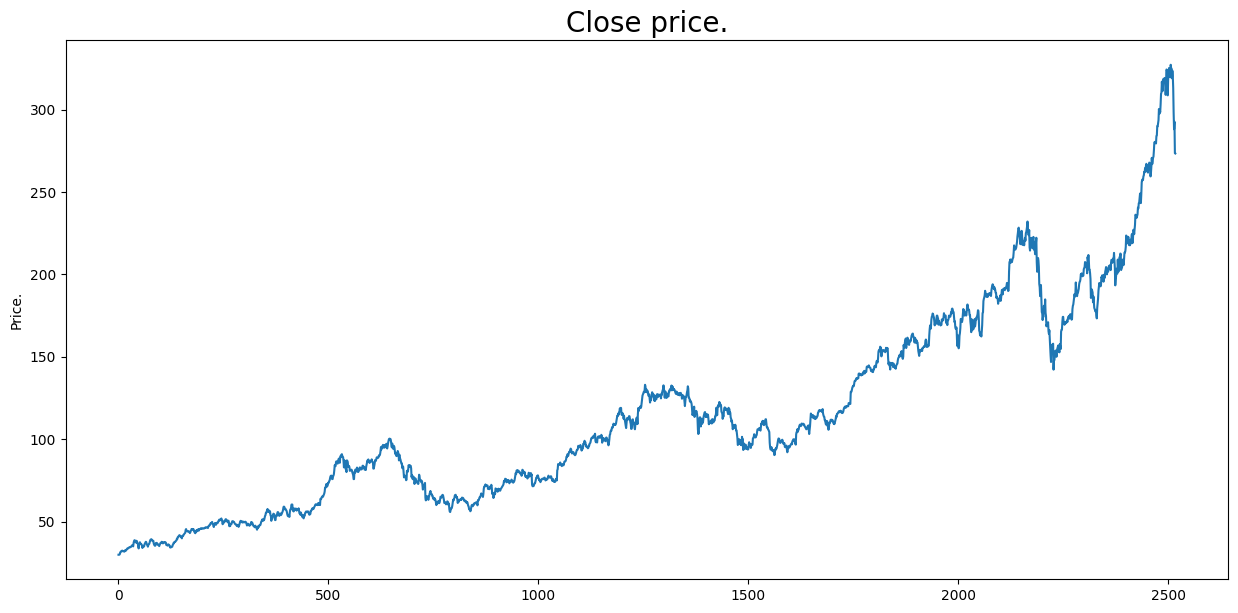

In [8]:
plt.figure(figsize=(15,7))
plt.plot(reversed_df[' Close/Last'])
plt.title('Close price.', fontsize=20)
plt.ylabel('Price.')
plt.show()

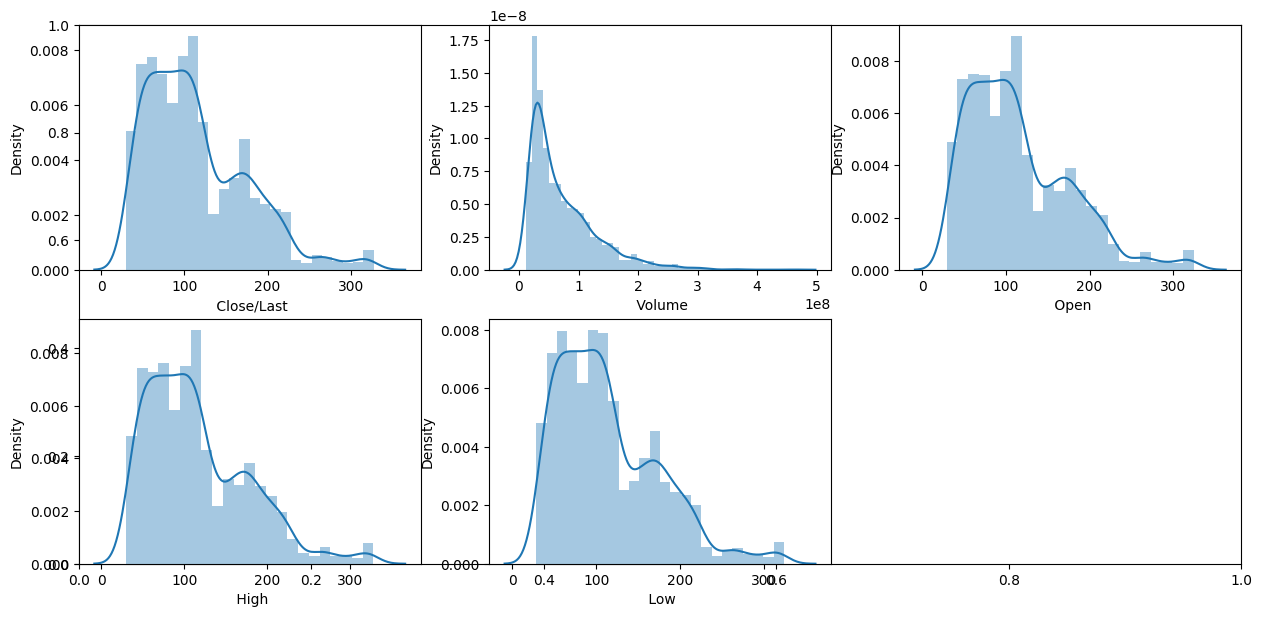

In [9]:
features = [' Close/Last', ' Volume', ' Open', ' High', ' Low']

plt.subplots(figsize=(15,7))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.distplot(reversed_df[col])
plt.show()

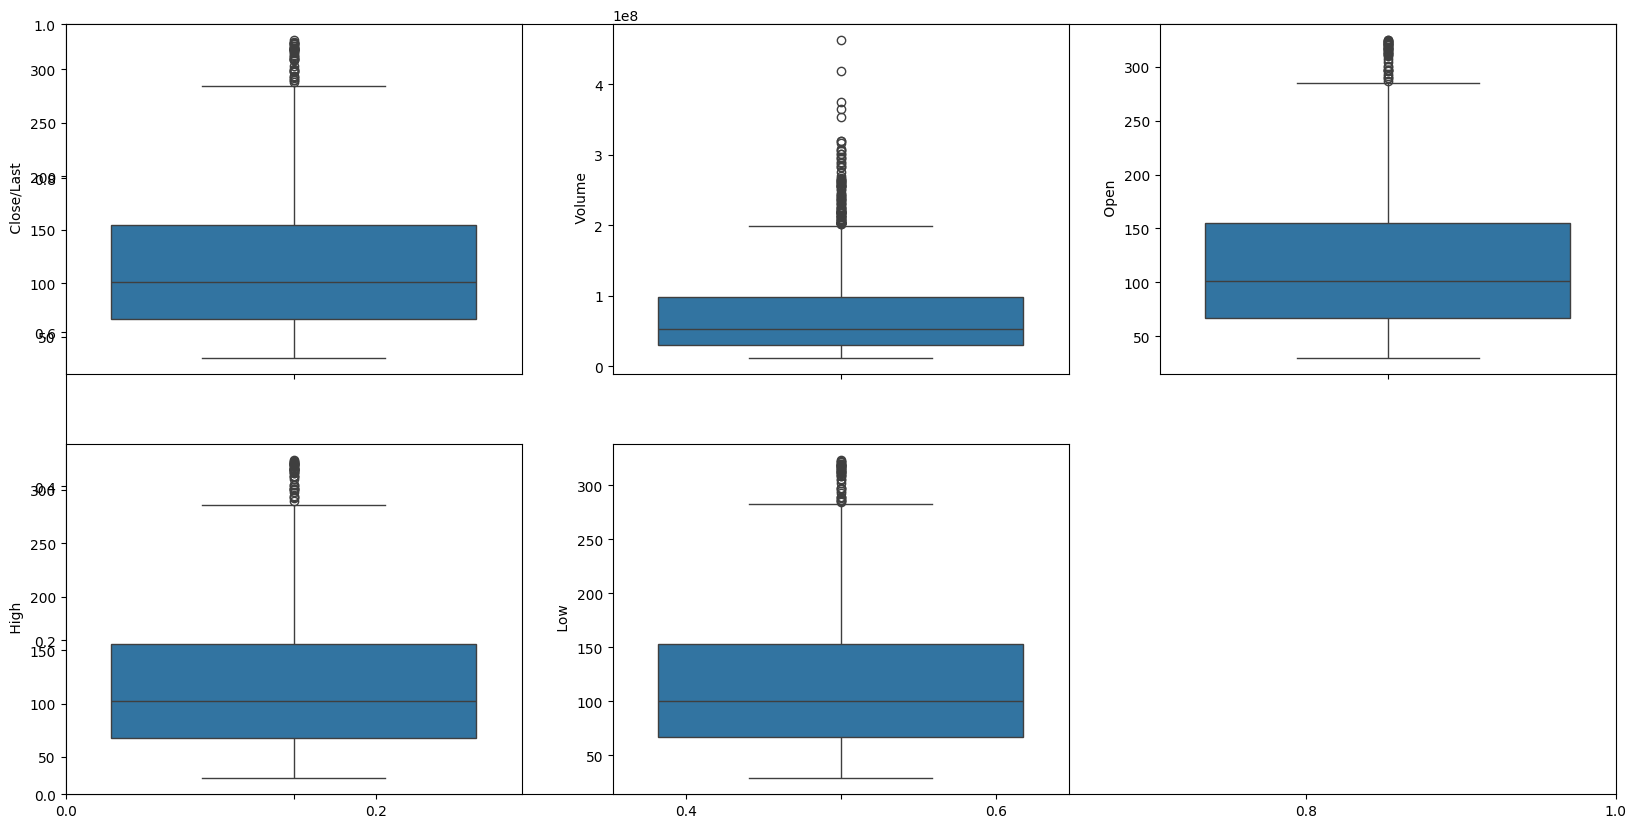

In [10]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.boxplot(reversed_df[col])
plt.show()

In [11]:
splitted = reversed_df['Date'].str.split('/', expand=True)

reversed_df['Month'] = splitted[0].astype('int')
reversed_df['Day'] = splitted[1].astype('int')
reversed_df['Year'] = splitted[2].astype('int')

reversed_df.head()

,Date,Close/Last,Volume,Open,High,Low,Month,Day,Year
0,03/01/2010,29.8557,137312041,29.3928,29.9286,29.3500,3,1,2010
1,03/02/2010,29.8357,141486282,29.9900,30.1186,29.6771,3,2,2010
2,03/03/2010,29.9043,92846488,29.8486,29.9814,29.7057,3,3,2010
3,03/04/2010,30.1014,89591907,29.8971,30.1314,29.8043,3,4,2010
4,03/05/2010,31.2786,224647427,30.7057,31.3857,30.6614,3,5,2010


In [12]:
reversed_df['Quarter_end'] = np.where(reversed_df['Month']%3==0,1,0)
reversed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         2518 non-null   object 
 1    Close/Last  2518 non-null   float64
 2    Volume      2518 non-null   int64  
 3    Open        2518 non-null   float64
 4    High        2518 non-null   float64
 5    Low         2518 non-null   float64
 6   Month        2518 non-null   int64  
 7   Day          2518 non-null   int64  
 8   Year         2518 non-null   int64  
 9   Quarter_end  2518 non-null   int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 196.8+ KB


In [13]:
reversed_df['Open-Last']  = reversed_df[' Open'] - reversed_df[' Close/Last']
reversed_df['Low-High']  = reversed_df[' Low'] - reversed_df[' High']
reversed_df['Target'] = np.where(reversed_df[' Close/Last'].shift(-1) > reversed_df[' Close/Last'], 1, 0)

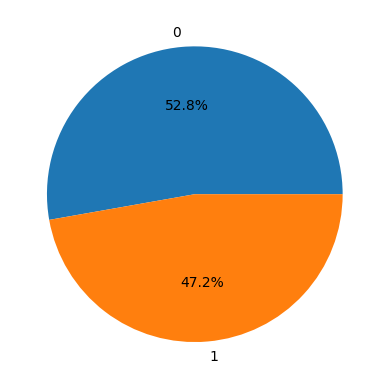

In [14]:
plt.pie(reversed_df['Target'].value_counts().values,
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

In [15]:
reversed_df = reversed_df.drop('Date', axis=1)

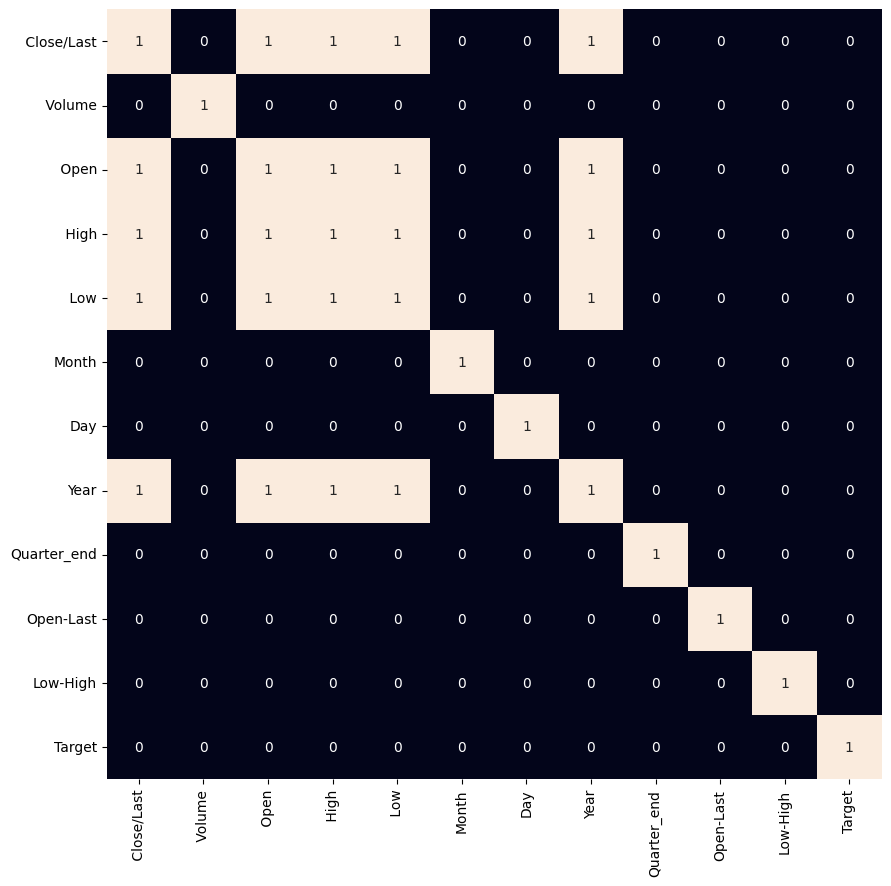

In [16]:
plt.figure(figsize=(10, 10))
sns.heatmap(reversed_df.corr() > 0.9, annot=True, cbar=False)
plt.show()

In [17]:
features = reversed_df[['Open-Last', 'Low-High', 'Quarter_end']]
target = reversed_df['Target']
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [18]:
X_train, X_valid, Y_train, Y_valid = train_test_split(
    features, target, test_size=0.1)
print(X_train.shape, X_valid.shape)

(2266, 3) (252, 3)


In [20]:
models = [LogisticRegression(), SVC(
  kernel='poly', probability=True)]

for i in range(2):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(
    Y_train, models[i].predict_proba(X_train)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(
    Y_valid, models[i].predict_proba(X_valid)[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.5331328387452533
Validation Accuracy :  0.4652847782258065

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.5379900743446447
Validation Accuracy :  0.47208921370967744



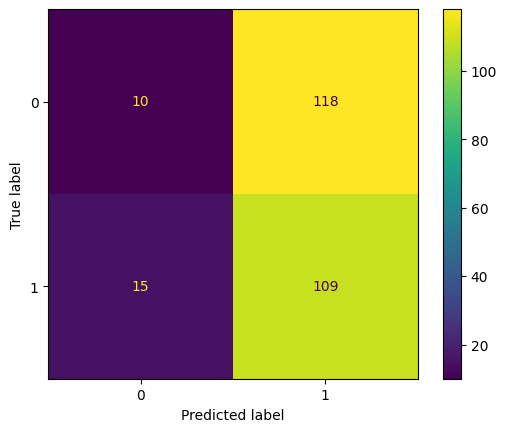

In [21]:
ConfusionMatrixDisplay.from_estimator(models[0], X_valid, Y_valid)